First, we need to load the necessary libraries

In [1]:
import pandas as pd # Used for data manipulation
import numpy as np # Used for numerical operations
import matplotlib.pyplot as plt # Used for plotting
import spacy # Used for text preprocessing and NLP tasks
from spacy import displacy # Used for visualizing NER results
from wordcloud import WordCloud # Used for creating word clouds

We also need to download the spaCy English model for NER. This only needs to be done once

In [2]:
#!python -m spacy download en_core_web_sm

Then, we download a dataset of central bank speeches. We are using the dataset from [cbspeeches.com](https://cbspeeches.com/) [@Campiglio2025], which contains a collection of speeches by central bankers from around the world.

In [3]:
import urllib.request
import os.path

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Check if the file exists
if not os.path.isfile("data/CBS_dataset_v1.0.dta"):

    print("Downloading dataset...")

    # Define the dataset to be downloaded
    fileurl = "https://www.dropbox.com/scl/fi/la5hpz39yht8mmoz0n98t/CBS_dataset_v1.0.dta?rlkey=jo0u8ktm1ixkwic4jw03re9c6&dl=1"

    # Define the filename to save the dataset
    filename = "data/CBS_dataset_v1.0.dta"

    # Download the dataset in the data folder
    urllib.request.urlretrieve(fileurl, filename)

    print("DONE!")

else:

    print("Dataset already downloaded!")

Dataset already downloaded!


Then, we load the dataset into a pandas DataFrame

In [4]:
speeches = pd.read_stata("data/CBS_dataset_v1.0.dta")
speeches = speeches.set_index("index")

We first filter the dataset to only include ECB speeches

In [5]:
ecb_speeches = speeches.query("CentralBank == 'European Central Bank'").copy()
ecb_speeches.head()

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source
index,,,,,,,,,,,,,,,
2976,https://www.ecb.europa.eu/press/key/date/2000/...,,One year with the euro,"Speech delivered by Dr Sirkka Hmlinen, Mem...",2000-01-08,Sirkka Hmlinen,Board member,Female,European Central Bank,ECB,One year with the euro Speech delivered by Dr ...,,ecb_000108.en,English,CB websites
2977,https://www.ecb.europa.eu/press/key/date/2000/...,,Opening Remarks at a Hearing of the Committee ...,"Professor Otmar Issing, Member of the Board o...",2000-01-10,Otmar Issing,Board member,Male,European Central Bank,ECB,Opening Remarks at a Hearing of the Committee ...,,ecb_000110.en,English,CB websites
2978,https://www.ecb.europa.eu/press/key/date/2000/...,,The international impact of the euro,"Speech delivered by Christian Noyer, Vice...",2000-01-13,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The international impact of the euro Speech de...,,ecb_000113.en,English,BIS
2979,https://www.ecb.europa.eu/press/key/date/2000/...,,The role of the central bank in encouraging an...,"Speech given by Christian Noyer, Vice-Pres...",2000-01-21,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The role of the central bank in encouraging an...,,ecb_000121.en,English,BIS
2980,https://www.ecb.europa.eu/press/key/date/2000/...,,The euro area - first experience and perspectives,"by Professor Otmar Issing, Member of the Boar...",2000-01-26,Otmar Issing,Board member,Male,European Central Bank,ECB,The euro area - first experience and perspecti...,,ecb_000126.en,English,CB websites


We have explored the dataset in the previous section, so we will skip that part here and go directly to using the dataset for NER. We will use the `en_core_web_sm` model from spaCy, which is a small English model that is suitable for NER tasks.


### Named Entity Recognition (NER) with spaCy

To perform NER, we first need to load the spaCy English model

In [6]:
# Load the spaCy English model
nlp = spacy.load("en_core_web_sm")

Then, we can take the text of a speech and process it using spaCy

In [7]:
# Get the text of the first speech
text = ecb_speeches.iloc[0]["text"]

# Process the text using spaCy
doc = nlp(text)

The named entities are stored in the `ents` attribute of the processed document. We can extract the text and the label of each entity and print them out

In [8]:
entities = [(ent.text, ent.label_) for ent in doc.ents]

for entity in entities[:10]:
    print(entity)

('One year', 'DATE')
('Speech', 'ORG')
('Sirkka Hamalainen', 'PERSON')
('the Executive Board', 'ORG')
('the European Central Bank', 'ORG')
('Europaisches Wochenende Berlin', 'PERSON')
('2000', 'DATE')
('Berlin', 'GPE')
('8 January 2000', 'DATE')
('First', 'ORDINAL')


or we can visualize the named entities using displaCy

In [9]:
displacy.render(doc[:100], style="ent", jupyter=True) # We only visualize the first 100 tokens to avoid rendering the entire speech

The named entities are not perfect. Sometimes, the model may miss some entities or misclassify them. However, it can still give us a good sense of the key players and topics that are mentioned in the speech. There are also more advanced models that can provide better results, such as the `en_core_web_trf` model, which is based on transformer architectures. However, it is also much slower to run, so we will stick with the smaller model for now.

Here is an overview of the different entity labels that spaCy can recognize:

In [10]:
print("Available entity types:", nlp.get_pipe("ner").labels)

Available entity types: ('CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART')


Let's extract the named entities for all the speeches in the dataset and store them in a new column in the DataFrame

In [11]:
def extract_entities(texts):

    # Convert the numpy array of texts to a list of strings
    text_list = texts.tolist()

    # Process each text using spaCy
    docs = nlp.pipe(text_list, disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"]) # We disable the components that we don't need to speed up the processing

    entities_list = []

    for doc in docs:
        entities_list.append([(ent.text, ent.label_) for ent in doc.ents])

    return pd.Series(entities_list, index=texts.index)

We will focus on the first 100 speeches to speed up the processing, as NER can be computationally intensive, especially for longer texts. We can always process more speeches later if needed.

In [12]:
entities_lists = extract_entities(ecb_speeches["text"].head(100)) # We only process the first 100 speeches to speed up the processing

Suppose we want to analyze which organizations are most frequently mentioned in the ECB speeches. We can extract all the entities that are labeled as "ORG" and count their frequencies

<Axes: >

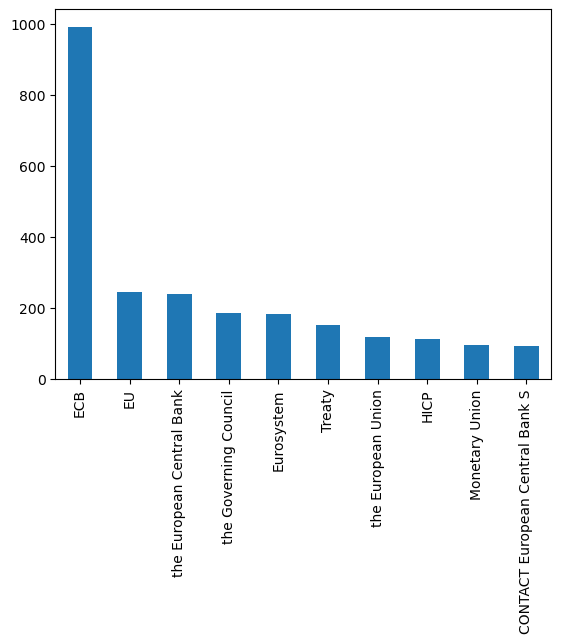

In [13]:
all_orgs = []
for entities in entities_lists:
    all_orgs.extend([ent[0] for ent in entities if ent[1] == "ORG"])
pd.Series(all_orgs).value_counts().head(10).plot(kind="bar")

Unsurprisingly, the most frequently mentioned organization is the "European Central Bank" itself, followed by other institutions.


### Combining NER with Dependency Parsing

A powerful feature of spaCy is that it allows us to combine NER with dependency parsing. This means that we can not only identify the named entities in a text, but also understand how they are related to each other. 

Suppose we want to extract the affiliation of the speaker in the speech. We can do this by looking for the named entity that is labeled as "PERSON" and then checking its dependency relations to find the organization it is affiliated with.

In [14]:
person_entities = [ent for ent in doc.ents if ent.label_ == "PERSON"]

The speaker is usually the first person entity mentioned in the speech, so we can take the first one from the list

In [15]:
speaker = person_entities[0]

We can also get all the organization entities in the speech

In [16]:
organization_entities = [ent for ent in doc.ents if ent.label_ == "ORG"]

Then, we can look at the dependency relations of the speaker entity to find the organization it is affiliated with.

Let's first visualize the dependencies of the first 20 tokens in the speech to get a sense of how the entities are related to each other

In [17]:
displacy.render(doc[:23], style="dep", options={'compact': True}, jupyter=True)

We can see that the speaker entity is related to an organization entity through the "appos" relation. We can extract this information programmatically as follows

In [18]:
for child in speaker.root.children:

    if child.dep_ == "appos":

        # Get the subtree of the appositive relation, which should contain the affiliation information
        subtree_start = child.left_edge.i
        subtree_end = child.right_edge.i + 1

        # Print the text of the subtree, which should contain the affiliation information
        print("Subtree: ", doc[subtree_start:subtree_end].text)

        # Select the last organization entity that is mentioned in the subtree
        for org in reversed(organization_entities):
            if org.start >= subtree_start and org.end <= subtree_end:
                print("Affiliation: ", org.text)
                break

        # We only consider the first appositive relation for simplicity, but there could be multiple ones in a speech
        break

Subtree:  Member of the Executive Board of the European Central Bank
Affiliation:  the European Central Bank


To make this operational and more robust can be a bit tricky, as the structure of the sentences can vary a lot across different speeches. However, dependency parsing can be a powerful tool to extract more complex relationships between entities in a text, and it can be combined with NER to get a richer understanding of the content of the speeches.